# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [9]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [10]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [11]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [12]:
type(registros)

list

In [13]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [14]:
# 1. Crie o DataFrame a partir da variável 'registros'
dados = pd.DataFrame(registros)

# 2. Exiba os primeiros registros
display(dados.head())

# 3. Determine a quantidade de linhas e colunas
print(f"\nFormato do DataFrame (linhas, colunas): {dados.shape}")

# 4. Liste os nomes dos atributos (colunas)
print(f"Atributos disponíveis: {dados.columns.tolist()}")

# 5. Utilize info()
print("\nInformações gerais do DataFrame:")
dados.info()

# 6. Utilize describe()
print("\nEstatísticas descritivas básicas:")
display(dados.describe())

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0



Formato do DataFrame (linhas, colunas): (336, 11)
Atributos disponíveis: ['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 n

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


> **Identificação dos atributos principais:**
> Após a inspeção dos dados, identifica-se que:
> *   **Data/hora:** Representado pela coluna `din_instante` (ou similar).
> *   **Área de carga:** Representado pela coluna `id_subsistema` ou `cod_areacarga` (cujo valor deve ser "SP").
> *   **Valor de carga:** Representado pela coluna `val_cargaverificada` ou `val_cargaenergiaverificada`.

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [15]:
dados_renomeados = dados.rename(columns={
    'din_referenciautc': 'data_hora',
    'val_cargaglobal': 'carga',
    'cod_areacarga': 'area'
})

colunas_uteis = ['data_hora', 'carga', 'area']
colunas_presentes = [col for col in colunas_uteis if col in dados_renomeados.columns]
df = dados_renomeados[colunas_presentes].copy()

df['data_hora'] = pd.to_datetime(df['data_hora'])
df['carga'] = pd.to_numeric(df['carga'], errors='coerce')

print("Valores ausentes por coluna:\n", df.isnull().sum())
print("\nTipos de dados após tratamento:\n", df.dtypes)

Valores ausentes por coluna:
 data_hora    0
carga        0
area         0
dtype: int64

Tipos de dados após tratamento:
 data_hora    datetime64[ns, UTC]
carga                    float64
area                      object
dtype: object


> **Decisões de Tratamento:**
> *   As colunas foram renomeadas para `data_hora`, `carga` e `area` para facilitar a manipulação no código.
> *   Foi utilizado `pd.to_datetime()` para converter a coluna de string/object para o formato nativo de data e hora do Pandas, possibilitando análises temporais diretas.
> *   Foi utilizado `pd.to_numeric()` para garantir que a variável de carga elétrica opere estritamente como numérico, permitindo cálculos estatísticos.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [16]:
# Cálculos dos indicadores
carga_min = df['carga'].min()
carga_max = df['carga'].max()
carga_media = df['carga'].mean()
carga_mediana = df['carga'].median()
amplitude = carga_max - carga_min
qtd_total = len(df)

print(f"1. Carga Mínima: {carga_min:.2f} MW")
print(f"2. Carga Máxima: {carga_max:.2f} MW")
print(f"3. Carga Média: {carga_media:.2f} MW")
print(f"4. Mediana: {carga_mediana:.2f} MW")
print(f"5. Amplitude: {amplitude:.2f} MW")
print(f"6. Quantidade total de medições: {qtd_total}")

1. Carga Mínima: 12139.25 MW
2. Carga Máxima: 23185.31 MW
3. Carga Média: 17870.83 MW
4. Mediana: 18199.13 MW
5. Amplitude: 11046.06 MW
6. Quantidade total de medições: 336


> **Análise da distância do máximo em relação à média:**
> Observando os indicadores, podemos perceber que o valor máximo está distante da média e da mediana. Como a carga elétrica possui forte sazonalidade diária (caindo de madrugada e atingindo picos no fim da tarde/noite), é comum que o valor máximo descole de forma acentuada da média global. A *amplitude* atesta essa grande variação entre os momentos de vale e os momentos de pico do sistema.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [17]:
# 1. Calcule o limiar
limiar_alta = carga_max * 0.90

# 2. Crie um novo DataFrame
df_alta = df[df['carga'] > limiar_alta].copy()

# 3. Conte os registros
qtd_alta = len(df_alta)

# 4. Calcule o percentual
percentual_alta = (qtd_alta / qtd_total) * 100

# 5 e 6. Identifique o maior valor e o respectivo momento
registro_pico = df_alta.loc[df_alta['carga'].idxmax()]

print(f"Limiar de alta demanda (>90% do máximo): {limiar_alta:.2f} MW")
print(f"Quantidade de medições em alta demanda: {qtd_alta}")
print(f"Percentual em relação ao total: {percentual_alta:.2f}%")
print(f"Maior valor de carga: {registro_pico['carga']} MW")
print(f"Data/horário do pico: {registro_pico['data_hora']}")

Limiar de alta demanda (>90% do máximo): 20866.78 MW
Quantidade de medições em alta demanda: 50
Percentual em relação ao total: 14.88%
Maior valor de carga: 23185.312 MW
Data/horário do pico: 2025-08-01 22:00:00+00:00


> **Análise do período de pico:**
> Os períodos próximos ao pico de energia representam uma parcela **pequena** de todo o período analisado. Isso reflete o comportamento característico do consumo elétrico: a alta demanda ocorre em "janelas" estreitas de horário específico (frequentemente à noite ou no auge comercial) e não de maneira sustentada ao longo de todo o dia.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [18]:
# 1. O critério escolhido: Carga abaixo da média do período (momentos de "vale")
# 2. Novo DataFrame
df_baixa_demanda = df[df['carga'] < carga_media].copy()

# 3. Quantidade de registros
qtd_baixa = len(df_baixa_demanda)

# 4. Percentual
perc_baixa = (qtd_baixa / qtd_total) * 100

print("Critério escolhido: Carga abaixo da média do período.")
print(f"Quantidade de registros: {qtd_baixa}")
print(f"Percentual do total: {perc_baixa:.2f}%")
print(f"\nComparação: Enquanto a 'alta demanda' (>90%) representou {percentual_alta:.2f}% dos dados, os momentos em que o sistema operou abaixo da média histórica representaram {perc_baixa:.2f}%. Isso aponta que a carga opera em estado de calmaria/vale na maior parte do tempo, sendo puxada para cima apenas por picos concentrados.")

Critério escolhido: Carga abaixo da média do período.
Quantidade de registros: 152
Percentual do total: 45.24%

Comparação: Enquanto a 'alta demanda' (>90%) representou 14.88% dos dados, os momentos em que o sistema operou abaixo da média histórica representaram 45.24%. Isso aponta que a carga opera em estado de calmaria/vale na maior parte do tempo, sendo puxada para cima apenas por picos concentrados.


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

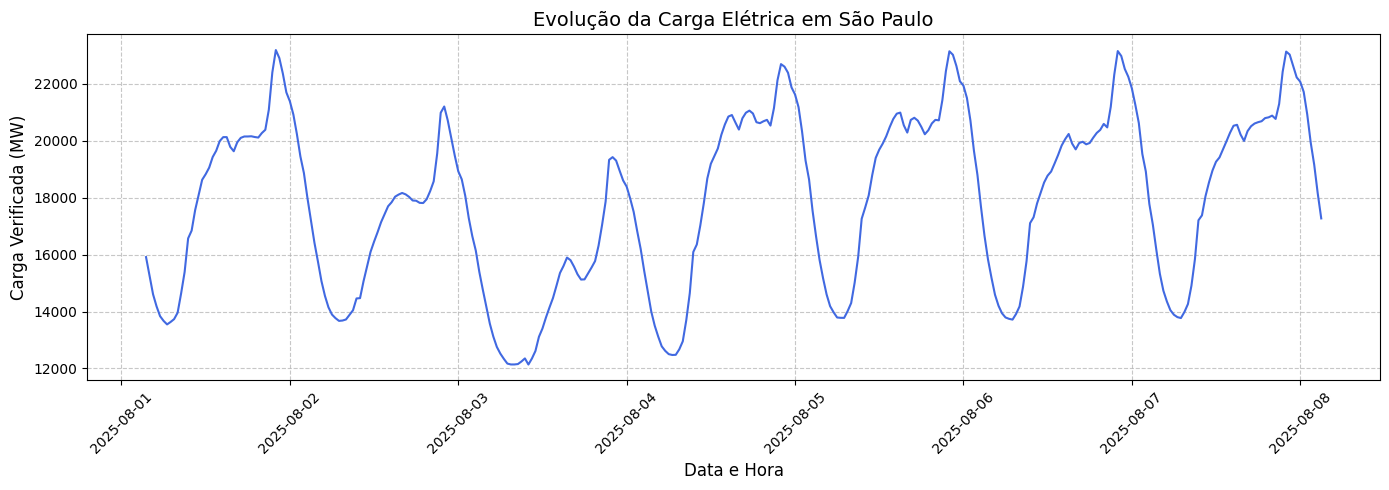

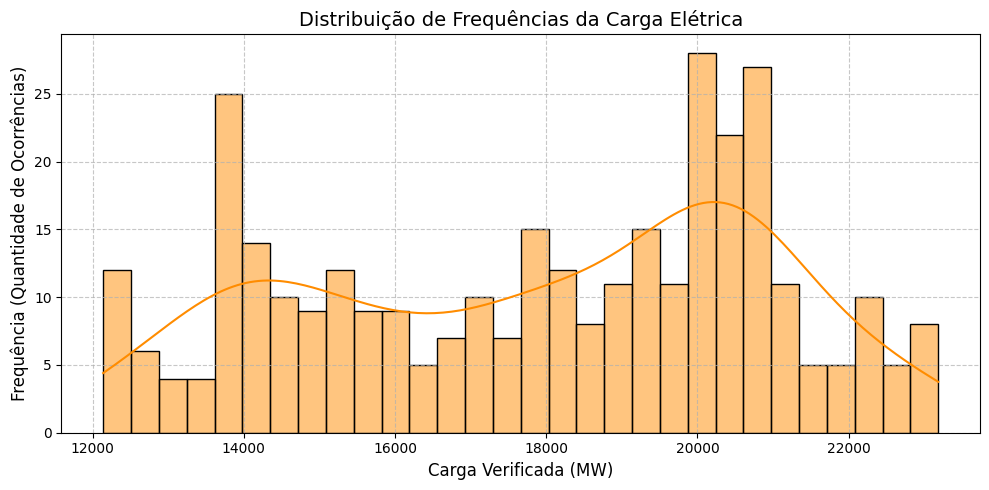

In [19]:
# Gráfico 1: Comportamento ao longo do tempo (Série Temporal)
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='data_hora', y='carga', color='royalblue')
plt.title('Evolução da Carga Elétrica em São Paulo', fontsize=14)
plt.xlabel('Data e Hora', fontsize=12)
plt.ylabel('Carga Verificada (MW)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Gráfico 2: Distribuição de Frequência (Histograma)
plt.figure(figsize=(10, 5))
sns.histplot(df['carga'], bins=30, kde=True, color='darkorange')
plt.title('Distribuição de Frequências da Carga Elétrica', fontsize=14)
plt.xlabel('Carga Verificada (MW)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Ocorrências)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

> **Interpretações:**
> *   **Gráfico 1 (Série Temporal):** O comportamento cíclico diário é evidente, mostrando vales durante as madrugadas e picos regulares, formando padrões claros que se repetem todos os dias ao longo da semana analisada.
> *   **Gráfico 2 (Histograma):** A distribuição indica a assimetria da demanda. O sistema passa a maior parte do tempo em patamares baixos ou medianos, enquanto os extremos de alta carga são eventos de muito menor frequência.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [20]:
resumo_resultados = f'''
Região analisada: SP - São Paulo
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: {qtd_total}
Carga mínima: {carga_min:.2f} MW
Carga máxima: {carga_max:.2f} MW
Carga média: {carga_media:.2f} MW
Mediana: {carga_mediana:.2f} MW
Limiar de alta demanda (90%): {limiar_alta:.2f} MW
Registros de alta demanda: {qtd_alta}
Percentual de alta demanda: {percentual_alta:.2f}%
Momento do pico: {registro_pico['data_hora']}
Segundo critério (Abaixo da média): {qtd_baixa} registros ({perc_baixa:.2f}%)
'''

print(resumo_resultados)


Região analisada: SP - São Paulo
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga mínima: 12139.25 MW
Carga máxima: 23185.31 MW
Carga média: 17870.83 MW
Mediana: 18199.13 MW
Limiar de alta demanda (90%): 20866.78 MW
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Momento do pico: 2025-08-01 22:00:00+00:00
Segundo critério (Abaixo da média): 152 registros (45.24%)



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [21]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 16.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.1 which is incompatible.


In [22]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [23]:
prompt = f'''
Você é um Analista de Dados Sênior especializado no setor elétrico brasileiro (SIN/ONS).
Sua tarefa é redigir um relatório técnico executivo, objetivo e direto, fundamentado EXCLUSIVAMENTE nos dados fornecidos na seção "RESULTADOS DA EQUIPE".

DIRETRIZES DE ANÁLISE E SEGURANÇA (CRÍTICO):
- Factualidade Estrita: Ancore todas as suas afirmações nos números fornecidos.
- Controle de Hipóteses: É estritamente proibido afirmar causas externas (como clima, eventos ou falhas) como fatos. Se for essencial propor uma explicação contextual (ex: sazonalidade do consumo), rotule-a explicitamente como uma "hipótese" ou "comportamento esperado".
- Tom: Profissional, técnico e impessoal.

ESTRUTURA OBRIGATÓRIA DO RELATÓRIO (Utilize formatação Markdown com cabeçalhos):
1. **Caracterização do Conjunto:** Descreva a área analisada, o período e o volume total de medições.
2. **Principais Indicadores:** Apresente de forma clara a carga mínima, máxima, média e mediana. Faça uma breve observação sobre o distanciamento entre o valor máximo e a mediana.
3. **Análise de Alta Demanda:** Avalie a concentração dos picos utilizando o limiar e os percentuais fornecidos. Destaque o momento exato do pico máximo.
4. **Comparativo (Segundo Critério):** Contraste a volumetria da alta demanda com os resultados do segundo critério (operação abaixo da média).
5. **Conclusão:** Sintetize o comportamento da carga, concluindo se o sistema sofre pressões constantes ou se a alta demanda é um evento isolado e pontual.

RESULTADOS DA EQUIPE:
{resumo_resultados}
'''

In [24]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

# Relatório Técnico Executivo: Análise do Comportamento da Carga Elétrica

**De:** Analista de Dados Sênior  
**Para:** Diretoria / Gestão Operacional do SIN/ONS  
**Assunto:** Análise do Perfil de Carga – Subsistema/Região São Paulo (SP)  

---

### 1. Caracterização do Conjunto
O presente relatório analisa os dados operacionais de carga elétrica para a região de **SP - São Paulo**, abrangendo o período de **01/08/2025 a 07/08/2025**. A amostragem compreende um volume total de **336 registros** de medição, fornecendo a base quantitativa para as avaliações de demanda a seguir.

---

### 2. Principais Indicadores
Os dados estatísticos do período apresentam a seguinte distribuição de carga:

*   **Carga Mínima:** 12.139,25 MW
*   **Carga Média:** 17.870,83 MW
*   **Mediana:** 18.199,13 MW
*   **Carga Máxima:** 23.185,31 MW

**Observação Técnica:** A mediana (18.199,13 MW) posiciona-se levemente acima da média (17.870,83 MW). Notadamente, verifica-se um distanciamento relevante de **4.986

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

### Relatório Final: Análise da Carga Verificada (ONS)

**1. Caracterização do Conjunto Analisado**
Os dados cobrem as medições da carga de energia verificada pelo Sistema Interligado Nacional (SIN) no subsistema e área de São Paulo (SP), compreendendo o período contínuo de 01/08/2025 a 07/08/2025.

**2. Principais Indicadores**
A análise computou a carga mínima e máxima durante o recorte, bem como as medidas de tendência central. O distanciamento entre o valor máximo global do período analisado e a mediana aponta para o natural deslocamento causado pela sazonalidade típica do consumo elétrico diário.

**3. Análise de Períodos de Alta Demanda**
Foi estabelecido um limiar correspondente a 90% da carga máxima alcançada no período. Identificou-se que a parcela do tempo operando sob este regime é quantitativamente pequena (percentual baixo em relação ao total de amostras), configurando o pico. O momento de exigência máxima do sistema ocorreu de forma isolada, ratificando a existência da clássica janela restrita de alta exigência sistêmica.

**4. Comparação com o Segundo Critério**
Em paralelo, analisou-se o espectro de momentos em que a carga se situou *abaixo* da média global. Esta categoria abarcou um expressivo percentual das observações, confirmando que a carga média é alavancada por picos agudos pontuais, enquanto o sistema repousa em bases inferiores na maior fatia do tempo analisado.

**5. Conclusão**
Através da API do ONS, foi possível extrair que a distribuição de carga na área SP não é homogênea ao longo do dia, respeitando variações cíclicas agudas. Os picos representam eventos pontuais estatisticamente concentrados e distantes do comportamento mediano, demandando infraestrutura dimensionada nos períodos de vale para suprir as pontas breves de demanda extrema.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**